# Elastic-Field Shape Matching — Differentiating Through Equilibrium


## Outline

1. Problem statement — optimize elastic parameters, not displacement
2. Adjoint path — the elastic Jacobian $\partial^2E/\partial u\,\partial b$
3. Setup — imports and output directory
4. Build a Koiter shell grid with an elastic field
5. Add gravity, generate a sagging target, and fix boundary DOFs
6. One forward + one gradient sanity check
7. The outer optimization loop (Adam)
8. Inspect the optimized elastic field
9. Recap and pitfalls


## 1. Problem statement — optimize elastic parameters, not displacement

We clamp the top edge of a shell, apply downward gravity, and let the
sheet relax to static equilibrium.  The design variable is the elastic
parameter field

$$
\mathbf b =
(E_m,\nu_m,E_b,\nu_b,h)_{e=1}^{n_\mathrm{tri}},
$$

one five-channel Koiter StVK row per triangle.  For each candidate
$\mathbf b$, the inner problem solves

$$
\mathbf u^\star(\mathbf b)
=\arg\min_{\mathbf u:\,\mathbf u_c=0}
\left(E_\mathrm{shell}(\mathbf u,\mathbf b)-\mathbf f_g^\top\mathbf u\right),
$$

and the outer problem matches the gravity-sagged surface to a target while
regularizing the elastic field toward its initial value:

$$
L(\mathbf b)=
\tfrac12\lVert \mathbf x_\mathrm{surf}(\mathbf b)-\hat{\mathbf x}\rVert^2
+\tfrac{\mu_\mathrm{reg}}2
\left\lVert\frac{\mathbf b-\mathbf b_0}{\mathbf s}\right\rVert^2 .
$$


## 2. Adjoint path — the elastic Jacobian

At equilibrium the free displacement DOFs satisfy
$\mathbf g_f(\mathbf u^\star,\mathbf b)=0$.  Differentiating this equation
with respect to elastic parameters gives

$$
\mathbf H_{ff}\frac{d\mathbf u_f^\star}{d\mathbf b}
+\mathbf J^b_f=0,\qquad
\mathbf J^b=\frac{\partial^2 E}{\partial \mathbf u\,\partial\mathbf b}.
$$

For a shape residual upstream gradient $\mathbf q=\partial L/\partial u$,
solve one adjoint system

$$
\mathbf H_{ff}\lambda_f=\mathbf q_f,
$$

then contract

$$
\nabla_{\mathbf b}L_\mathrm{shape}
=-(\mathbf J^b)^\top\lambda .
$$

In pypgo this is the elastic counterpart of the plastic layer:
`ElasticStaticEquilibriumLayer.backward` calls
`energy.elastic_jacobian(u)`, while `PlasticStaticEquilibriumLayer`
calls `energy.plastic_jacobian(u)`.


## 3. Setup — imports and output directory

The differentiable equilibrium layer currently expects CPU `float64`
tensors.  We keep the mesh small so the notebook runs quickly.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypgo as pgo
import pypgo.energy as pe
import pypgo.fem as pf
import pypgo.solver as ps
import torch

PACKAGE_ROOT = Path(pgo.__file__).resolve().parent.parent
OUTPUT_DIR = PACKAGE_ROOT / "examples" / "outputs" / "elastic_material_optimization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=5, suppress=True)
torch.set_default_dtype(torch.float64)


## 4. Build a Koiter shell grid with an elastic field

The volumetric `StableNeo` / `StVK` paths in this build take elastic
constants from the simulation mesh material and expose zero elastic
optimization channels.  Koiter shells already expose the intended elastic
field: five channels per triangle.  We therefore use a square shell grid
and an `ElementwiseField`, mirroring the plastic demo's elementwise design
space.


In [2]:
nx = ny = 5

def vertex_id(i, j):
    return i * (ny + 1) + j

vertices = np.array(
    [[i / nx, j / ny, 0.0] for i in range(nx + 1) for j in range(ny + 1)],
    dtype=np.float64,
)
triangles = []
for i in range(nx):
    for j in range(ny):
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j), vertex_id(i + 1, j + 1)])
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j + 1), vertex_id(i, j + 1)])
triangles = np.asarray(triangles, dtype=np.int64)
surface = pgo.mesh.TriMeshData(vertices, triangles)

shell_mat = pf.KoiterStVKShellMaterial(
    thickness=1.0e-3,
    E_membrane=2.0e4,
    nu_membrane=0.35,
)
sim = pf.SimulationMesh.create_shell(surface, shell_mat)

base_elastic_row = np.array([2.0e4, 0.35, 1.0e4, 0.25, 1.0e-3], dtype=np.float64)
initial_elastic = np.tile(base_elastic_row, (triangles.shape[0], 1))

centers = vertices[triangles].mean(axis=1)
plastic_values = np.ones((triangles.shape[0], 1), dtype=np.float64)

energy = pf.deformation_energy(
    sim,
    elastic=pf.KoiterStVK(),
    elastic_field=pf.ElementwiseField(values=initial_elastic),
    plastic=pf.ShellPlasticity(dofs=1),
    plastic_field=pf.ElementwiseField(values=plastic_values),
    formulation=pf.KoiterShell(),
    options=pf.DeformationOptions(enforce_spd=False, enable_material_max_step=False),
)

print("shell grid:", nx, "x", ny, "->", surface.num_vertices, "vertices,", surface.num_elements, "triangles")
print("elastic field shape:", energy.elastic_field.values.shape,
      "| elastic dofs:", energy.num_elastic_dofs)
print("plastic field is rest-state and fixed, shape:", energy.plastic_field.values.shape)
pgo.mesh.plot_surface(surface, titles=["rest shell grid"], colors=["lightgray"], show_edges=True)


[2026-06-09 22:01:46.962] [info] [deformationModelManager.cpp:248] Initializing element models (manager path)...
[2026-06-09 22:01:46.963] [info] [deformationModelAssembler.cpp:227] Assembler parameter channels:5,1 local:5,1
shell grid: 5 x 5 -> 36 vertices, 50 triangles
elastic field shape: (50, 5) | elastic dofs: 250
plastic field is rest-state and fixed, shape: (50, 1)


Widget(value='<iframe src="http://localhost:63215/index.html?ui=P_0x31392b890_0&reconnect=auto" class="pyvista…

## 5. Add gravity, generate a sagging target, and fix boundary DOFs

We clamp the top edge ($y=1$), apply downward gravity, and build a
synthetic target by solving the same gravity-loaded system with a hidden
softer/thinner elastic field.  In your own fitting run, replace only
`target_vertices`; the rest of the pipeline is the same.


In [3]:
shear_strength = 0.0
sag_strength = 20.0

# Lumped shell gravity: triangle area / 3 to each incident vertex.
vertex_area = np.zeros(vertices.shape[0], dtype=np.float64)
for tri in triangles:
    a, b, c = vertices[tri]
    area = 0.5 * np.linalg.norm(np.cross(b - a, c - a))
    vertex_area[tri] += area / 3.0
areal_density = 1.0
gravity_accel = np.array([0.0, 0.0, -sag_strength], dtype=np.float64)
gravity_force = np.zeros(energy.num_dofs, dtype=np.float64)
gravity_force.reshape((-1, 3))[:] = areal_density * vertex_area[:, None] * gravity_accel
gravity_energy = pe.LinearEnergy(-gravity_force)
objective = pe.EnergySet([(energy, 1.0), (gravity_energy, 1.0)])

fixed_vertices = np.flatnonzero(np.isclose(vertices[:, 1], 1.0)).astype(np.int64)
fixed_dofs = (3 * fixed_vertices[:, None] + np.arange(3, dtype=np.int64)).ravel()
fixed_values = np.zeros(fixed_dofs.size, dtype=np.float64)
free_dofs = np.setdiff1d(np.arange(energy.num_dofs, dtype=np.int64), fixed_dofs)

def solve_surface_for_elastic(elastic_values):
    energy.set_elastic_values(elastic_values)
    problem = ps.OptimizationProblem(objective=objective)
    problem.fix_variables(fixed_dofs.tolist(), fixed_values, num_dofs=energy.num_dofs)
    result = ps.NewtonOptimizer(
        max_iterations=80,
        gradient_tolerance=1e-9,
        damping=True,
        line_search=ps.Backtrack(),
    ).solve(problem, energy.zero_state())
    if not result.converged:
        print("target solve warning:", result.status.name, "grad:", result.final_gradient_max_norm)
    return vertices + result.x.reshape((-1, 3))

# Hidden target material: softer and thinner near the free lower middle.
distance_from_clamp = 1.0 - centers[:, 1]
center_band = np.exp(-((centers[:, 0] - 0.5) / 0.75) ** 2)
softness = (distance_from_clamp ** 0.8) * center_band
target_elastic = initial_elastic.copy()
target_elastic[:, 0] *= 1.0 - 0.95 * softness
target_elastic[:, 2] *= 1.0 - 0.95 * softness
target_elastic[:, 4] *= 1.0 - 0.90 * softness
target_vertices = solve_surface_for_elastic(target_elastic)
target_vertices[:, 0] += shear_strength * (1.0 - vertices[:, 1]) * np.sin(np.pi * vertices[:, 0])
target_surface = pgo.mesh.TriMeshData(target_vertices, triangles)
energy.set_elastic_values(initial_elastic)

equilibrium_layer = pgo.fem.ElasticStaticEquilibriumLayer(
    energy=energy,
    objective_energy=objective,
    fixed_dofs=fixed_dofs,
    fixed_values=fixed_values,
    surface_vertices=vertices,
    surface_vertex_ids=np.arange(vertices.shape[0], dtype=np.int64),
    inner_optimizer=ps.NewtonOptimizer(
        max_iterations=80,
        gradient_tolerance=1e-9,
        damping=True,
        line_search=ps.Backtrack(),
    ),
)

b0 = energy.elastic_field.values.ravel().copy()
b0_torch = torch.as_tensor(b0, dtype=torch.float64)
target_vertices_torch = torch.as_tensor(target_vertices, dtype=torch.float64)

print("gravity force norm:", float(np.linalg.norm(gravity_force)))
print("fixed top-edge vertices:", fixed_vertices.size,
      "| free dofs:", free_dofs.size, "of", energy.num_dofs)
pgo.mesh.plot_surface(
    [surface, target_surface],
    titles=["rest shell", "target gravity sag"],
    colors=["lightgray", "palegreen"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-09 22:01:50.028] [info] [NewtonSolver.cpp:416] Newton solve time: 0.010206
gravity force norm: 3.6024682896283458
fixed top-edge vertices: 6 | free dofs: 90 of 108


Widget(value='<iframe src="http://localhost:63215/index.html?ui=P_0x31ef37d70_1&reconnect=auto" class="pyvista…

## 6. One forward + one gradient sanity check

This cell exercises the full PyTorch operator once: forward equilibrium,
shape loss, explicit elastic regularizer, and adjoint backward through
`energy.elastic_jacobian`.


In [4]:
def vertex_error_stats(residual):
    vertex_errors = np.linalg.norm(residual, axis=1)
    global_error = float(np.linalg.norm(residual.ravel()))
    return {
        "global_error": global_error,
        "per_vertex_rms": global_error / np.sqrt(residual.shape[0]),
        "mean_vertex_error": float(vertex_errors.mean()),
        "max_vertex_error": float(vertex_errors.max()),
    }

def print_error_stats(label, stats):
    print(
        f"{label}: global={stats['global_error']:.6f}  "
        f"per-vertex RMS={stats['per_vertex_rms']:.6f}  "
        f"mean={stats['mean_vertex_error']:.6f}  "
        f"max={stats['max_vertex_error']:.6f}"
    )

scale_row = np.array([2.0e4, 1.0, 1.0e4, 1.0, 1.0e-3], dtype=np.float64)
scale = np.tile(scale_row, surface.num_elements)
l2_weight = 2.0e-4
lower_row = np.array([1.0e3, 0.05, 5.0e2, 0.05, 1.0e-4], dtype=np.float64)
upper_row = np.array([6.0e4, 0.48, 4.0e4, 0.48, 2.5e-3], dtype=np.float64)
lower = np.tile(lower_row, surface.num_elements)
upper = np.tile(upper_row, surface.num_elements)
lower_design = (lower - b0) / scale
upper_design = (upper - b0) / scale


In [5]:
design = torch.zeros_like(b0_torch, requires_grad=True)
elastic_param = b0_torch + torch.as_tensor(scale) * design
initial_vertices = equilibrium_layer(elastic_param)
initial_residual = initial_vertices - target_vertices_torch
initial_shape_loss = 0.5 * torch.sum(initial_residual ** 2)
initial_regularization = 0.5 * l2_weight * torch.sum(design ** 2)
initial_loss = initial_shape_loss + initial_regularization
initial_loss.backward()

elastic_jacobian = energy.elastic_jacobian(equilibrium_layer.last_equilibrium_displacement)
print("initial objective L(b0):", float(initial_loss.detach()))
print_error_stats("initial shape error", vertex_error_stats(initial_residual.detach().numpy()))
print("elastic_jacobian shape:", elastic_jacobian.shape)
print("gradient norm ||dL/dz||:", float(torch.linalg.norm(design.grad)))

initial_surface = pgo.mesh.TriMeshData(initial_vertices.detach().numpy(), triangles)
print("rest z range:   ", (float(vertices[:, 2].min()), float(vertices[:, 2].max())))
print("initial z range:", (float(initial_surface.vertices[:, 2].min()), float(initial_surface.vertices[:, 2].max())))
print("target z range: ", (float(target_vertices[:, 2].min()), float(target_vertices[:, 2].max())))
pgo.mesh.plot_surface(
    [surface, target_surface, initial_surface],
    titles=["rest", "target", "initial equilibrium (b = b0)"],
    colors=["lightgray", "palegreen", "lightskyblue"],
    show_edges=True,
    window_size=(1200, 420),
)


[2026-06-09 22:02:08.302] [info] [NewtonSolver.cpp:416] Newton solve time: 0.015403
initial objective L(b0): 0.11547924868116617
initial shape error: global=0.480581  per-vertex RMS=0.080097  mean=0.059802  max=0.177478
elastic_jacobian shape: (108, 250)
gradient norm ||dL/dz||: 0.061566420525365304
rest z range:    (0.0, 0.0)
initial z range: (-1.0859193310058746, 0.0)
target z range:  (-1.26110228793423, 0.0)


Widget(value='<iframe src="http://localhost:63215/index.html?ui=P_0x31f01d280_2&reconnect=auto" class="pyvista…

## 7. The outer optimization loop (Adam)

The loop is the same bilevel pattern as the plastic notebook:

1. Map normalized design `z` to physical parameters `b = b0 + scale * z`.
2. `equilibrium_layer(elastic_param)` solves the gravity-loaded inner equilibrium.
3. We evaluate shape loss plus an explicit elastic-field prior.
4. `loss.backward()` computes the adjoint gradient.
5. Adam updates the normalized design, followed by a simple projection onto
   physically reasonable parameter bounds.


In [6]:
num_outer_steps = 80
learning_rate = 0.08
design = torch.zeros_like(b0_torch, requires_grad=True)
scale_torch = torch.as_tensor(scale, dtype=torch.float64)
lower_design_torch = torch.as_tensor(lower_design, dtype=torch.float64)
upper_design_torch = torch.as_tensor(upper_design, dtype=torch.float64)
outer_optimizer = torch.optim.Adam([design], lr=learning_rate)
history = []
best_value = np.inf
best_design = np.zeros_like(b0)
best_displacement = energy.zero_state()

for iteration in range(num_outer_steps):
    outer_optimizer.zero_grad()
    elastic_param = b0_torch + scale_torch * design
    solved_vertices = equilibrium_layer(elastic_param)
    residual = solved_vertices - target_vertices_torch
    shape_loss = 0.5 * torch.sum(residual ** 2)
    regularization = 0.5 * l2_weight * torch.sum(design ** 2)
    loss = shape_loss + regularization
    loss.backward()

    value = float(loss.detach())
    stats = vertex_error_stats(residual.detach().numpy())
    if value < best_value:
        best_value = value
        best_design = design.detach().numpy().copy()
        best_displacement = equilibrium_layer.last_equilibrium_displacement
    outer_optimizer.step()
    with torch.no_grad():
        design.copy_(torch.minimum(torch.maximum(design, lower_design_torch), upper_design_torch))
    history.append((value, stats["global_error"], stats["mean_vertex_error"]))
    if iteration < 5 or (iteration + 1) % 10 == 0:
        print(
            f"step {iteration + 1:3d}  objective={value:.6f}  "
            f"global_error={stats['global_error']:.6f}  "
            f"mean_vertex={stats['mean_vertex_error']:.6f}  "
            f"grad={float(torch.linalg.norm(design.grad)):.6e}"
        )

print(f"\nbest objective over {num_outer_steps} steps: {best_value:.6f}")


[2026-06-09 22:02:19.353] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000226
step   1  objective=0.115479  global_error=0.480581  mean_vertex=0.059802  grad=6.156642e-02
[2026-06-09 22:02:19.359] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002452
step   2  objective=0.080682  global_error=0.401437  mean_vertex=0.048791  grad=4.105742e-02
[2026-06-09 22:02:19.364] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002043
step   3  objective=0.054293  global_error=0.328415  mean_vertex=0.040785  grad=3.069713e-02
[2026-06-09 22:02:19.369] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002564
step   4  objective=0.036528  global_error=0.267565  mean_vertex=0.035602  grad=2.042605e-02
[2026-06-09 22:02:19.374] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002332
step   5  objective=0.030007  global_error=0.239956  mean_vertex=0.034337  grad=1.878579e-02
[2026-06-09 22:02:19.380] [info] [NewtonSolver.cpp:416] Newton solve time: 0.003611
[2026-06-09 22:02:19.384] [info

### Evaluate the best design and save the result

Reset the warm start, re-solve at the best elastic field, and save the
optimized field plus geometry for downstream inspection.


In [7]:
best_elastic = b0 + scale * best_design
optimized_elastic_tensor = torch.as_tensor(best_elastic, dtype=torch.float64)
equilibrium_layer.reset_warm_start(best_displacement)
optimized_vertices = equilibrium_layer(optimized_elastic_tensor).detach().numpy().copy()
final_residual = optimized_vertices - target_vertices
final_shape_value = 0.5 * float(np.dot(final_residual.ravel(), final_residual.ravel()))
final_regularization = 0.5 * l2_weight * float(np.dot((best_elastic - b0) / scale, (best_elastic - b0) / scale))
final_value = final_shape_value + final_regularization

print("final objective:", final_value,
      "(shape:", final_shape_value, "+ reg:", final_regularization, ")")
print_error_stats("final shape error", vertex_error_stats(final_residual))

optimized_elastic = best_elastic.reshape(energy.elastic_field.values.shape)
elastic_delta = optimized_elastic - initial_elastic
elastic_delta_norm = np.linalg.norm(elastic_delta / scale_row, axis=1)
E_membrane_delta = elastic_delta[:, 0]
thickness_delta = elastic_delta[:, 4]

print("optimized elastic sample rows (E_m,nu_m,E_b,nu_b,h):")
print(optimized_elastic[: min(8, optimized_elastic.shape[0])])

weight_path = OUTPUT_DIR / "elastic_shape_match_weights.npz"
np.savez(
    weight_path,
    initial_elastic=initial_elastic,
    optimized_elastic=optimized_elastic,
    elastic_delta=elastic_delta,
    elastic_delta_norm=elastic_delta_norm,
    E_membrane_delta=E_membrane_delta,
    thickness_delta=thickness_delta,
    vertices=vertices,
    triangles=triangles,
    target_vertices=target_vertices,
    optimized_vertices=optimized_vertices,
    plastic_values=plastic_values,
    gravity_force=gravity_force,
    target_elastic=target_elastic,
)
print("saved elastic weights ->", weight_path)

optimized_surface = pgo.mesh.TriMeshData(optimized_vertices, triangles)
pgo.mesh.plot_surface(
    [target_surface, optimized_surface],
    titles=["target", "optimized equilibrium"],
    colors=["palegreen", "salmon"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-09 22:02:22.415] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000227
final objective: 0.002464702797914729 (shape: 7.287052410126672e-05 + reg: 0.0023918322738134623 )
final shape error: global=0.012072  per-vertex RMS=0.002012  mean=0.001564  max=0.005469
optimized elastic sample rows (E_m,nu_m,E_b,nu_b,h):
[[ 5899.86584     0.33709 10006.27217     0.24906     0.00029]
 [11145.85676     0.46863 10006.30454     0.25096     0.00056]
 [ 8218.50273     0.40992 10005.04823     0.25007     0.00041]
 [ 9942.88657     0.31635  9995.66942     0.24958     0.0005 ]
 [11801.21476     0.36781 10005.06832     0.24957     0.00059]
 [12751.66735     0.32914 10008.20948     0.2509      0.00064]
 [14523.84895     0.34285 10008.15352     0.25078     0.00073]
 [16719.46765     0.31709 10008.71306     0.25075     0.00084]]
saved elastic weights -> /Users/jinceyang/Desktop/codebase/libpgo/examples/outputs/elastic_material_optimization/elastic_shape_match_weights.npz


Widget(value='<iframe src="http://localhost:63215/index.html?ui=P_0x31f01f530_3&reconnect=auto" class="pyvista…

### Convergence history


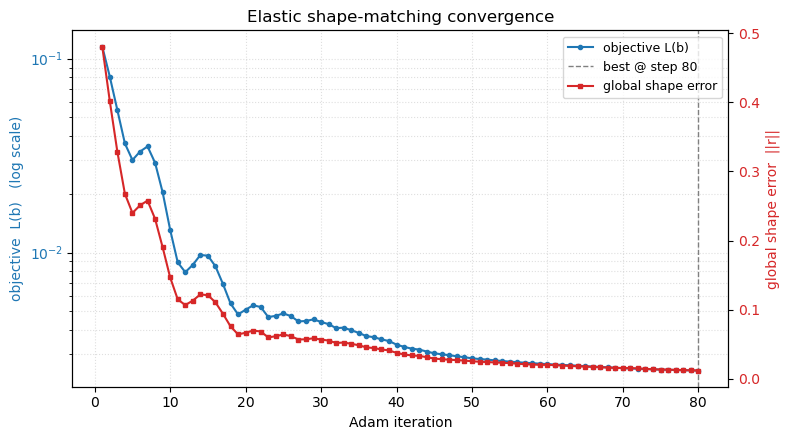

In [8]:
objective_hist = np.array([h[0] for h in history])
global_hist = np.array([h[1] for h in history])
steps = np.arange(1, len(history) + 1)
best_step = int(np.argmin(objective_hist)) + 1

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.semilogy(steps, objective_hist, color="tab:blue", marker="o", ms=3, lw=1.5,
             label="objective L(b)")
ax1.axvline(best_step, color="gray", ls="--", lw=1.0, label=f"best @ step {best_step}")
ax1.set_xlabel("Adam iteration")
ax1.set_ylabel("objective  L(b)   (log scale)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, which="both", ls=":", alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(steps, global_hist, color="tab:red", marker="s", ms=3, lw=1.5,
         label="global shape error")
ax2.set_ylabel("global shape error  ||r||", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
ax1.set_title("Elastic shape-matching convergence")
fig.tight_layout()
plt.show()


## 8. Inspect the optimized elastic field

We visualize elementwise parameter changes on the rest triangulation.
`elastic_delta_norm` is normalized channel-wise so membrane stiffness and
thickness can be compared on one scalar map.


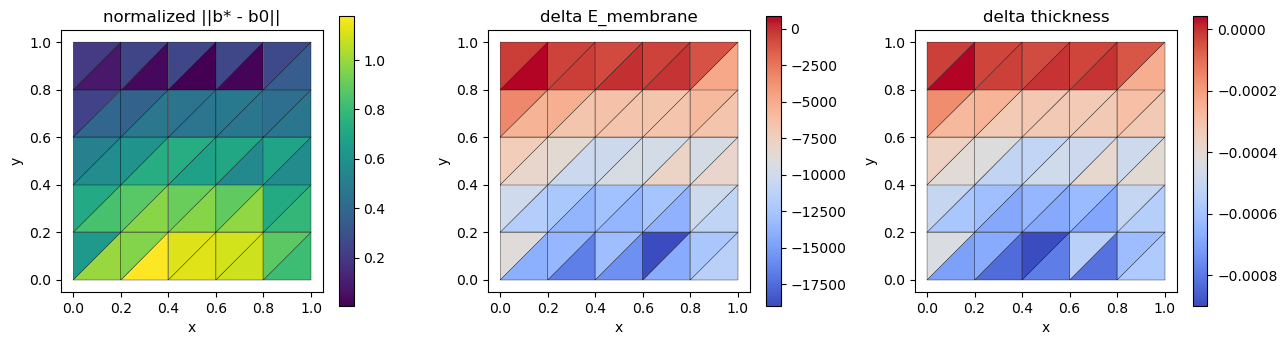

In [9]:
def plot_element_scalar(ax, values, title, cmap="viridis"):
    triang = ax.tripcolor(
        vertices[:, 0],
        vertices[:, 1],
        triangles,
        facecolors=values,
        edgecolors="k",
        linewidth=0.25,
        cmap=cmap,
        shading="flat",
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(triang, ax=ax, shrink=0.8)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_element_scalar(axes[0], elastic_delta_norm, "normalized ||b* - b0||")
plot_element_scalar(axes[1], E_membrane_delta, "delta E_membrane", cmap="coolwarm")
plot_element_scalar(axes[2], thickness_delta, "delta thickness", cmap="coolwarm")
fig.tight_layout()
plt.show()


## 9. Recap and pitfalls

- `ElasticStaticEquilibriumLayer` is the elastic analogue of
  `PlasticStaticEquilibriumLayer`.
- The backward pass uses `energy.elastic_jacobian(u)`:
  $\partial^2E/\partial u\,\partial b$.
- Purely scaling every elastic parameter often does not change the
  equilibrium shape much; the useful design space here is the *spatial
  distribution* of stiffness and thickness.
- Bounds matter: unconstrained elastic constants can become negative or
  leave the stable range of Poisson ratios.
